In [2]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

print("MindMate ML environment is working!")

MindMate ML environment is working!


In [3]:
import pandas as pd
import os

print("Current project folder:")
print(os.getcwd())

print("\nData folder contents:")
print(os.listdir("../data/raw"))

Current project folder:
/Users/tarinisharma/Documents/mindmate-ai/notebooks

Data folder contents:
['.gitkeep']


In [4]:
import os

project_root = os.path.abspath("..")

print("Project root:")
print(project_root)

print("\nRaw data folder:")
print(os.path.join(project_root, "data", "raw"))

Project root:
/Users/tarinisharma/Documents/mindmate-ai

Raw data folder:
/Users/tarinisharma/Documents/mindmate-ai/data/raw


In [5]:
from datasets import load_dataset

print("Loading GoEmotions dataset...")

dataset = load_dataset("google-research-datasets/go_emotions")

print("Dataset loaded successfully!")
print(dataset)

Loading GoEmotions dataset...


Dataset loaded successfully!
DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})


In [6]:
print(dataset["train"].features)

{'text': Value('string'), 'labels': List(ClassLabel(names=['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral'])), 'id': Value('string')}


In [7]:
print(dataset["train"][0])

{'text': "My favourite food is anything I didn't have to cook myself.", 'labels': [27], 'id': 'eebbqej'}


In [8]:
emotion_names = dataset["train"].features["labels"].feature.names

print(emotion_names)

['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


In [9]:
def get_emotion_name(label):
    return emotion_names[label]

print(get_emotion_name(27))
print(get_emotion_name(14))
print(get_emotion_name(25))

neutral
fear
sadness


In [10]:
from collections import Counter

train_labels = dataset["train"]["labels"]

# Each example can have more than one emotion,
# so we flatten the label lists.
all_labels = []

for labels in train_labels:
    all_labels.extend(labels)

label_counts = Counter(all_labels)

emotion_distribution = {
    emotion_names[label]: count
    for label, count in label_counts.items()
}

print(emotion_distribution)

{'neutral': 14219, 'anger': 1567, 'fear': 596, 'annoyance': 2470, 'surprise': 1060, 'gratitude': 2662, 'desire': 641, 'optimism': 1581, 'admiration': 4130, 'confusion': 1368, 'amusement': 2328, 'approval': 2939, 'caring': 1087, 'embarrassment': 303, 'realization': 1110, 'disappointment': 1269, 'grief': 77, 'sadness': 1326, 'curiosity': 2191, 'joy': 1452, 'love': 2086, 'excitement': 853, 'disapproval': 2022, 'remorse': 545, 'disgust': 793, 'relief': 153, 'pride': 111, 'nervousness': 164}


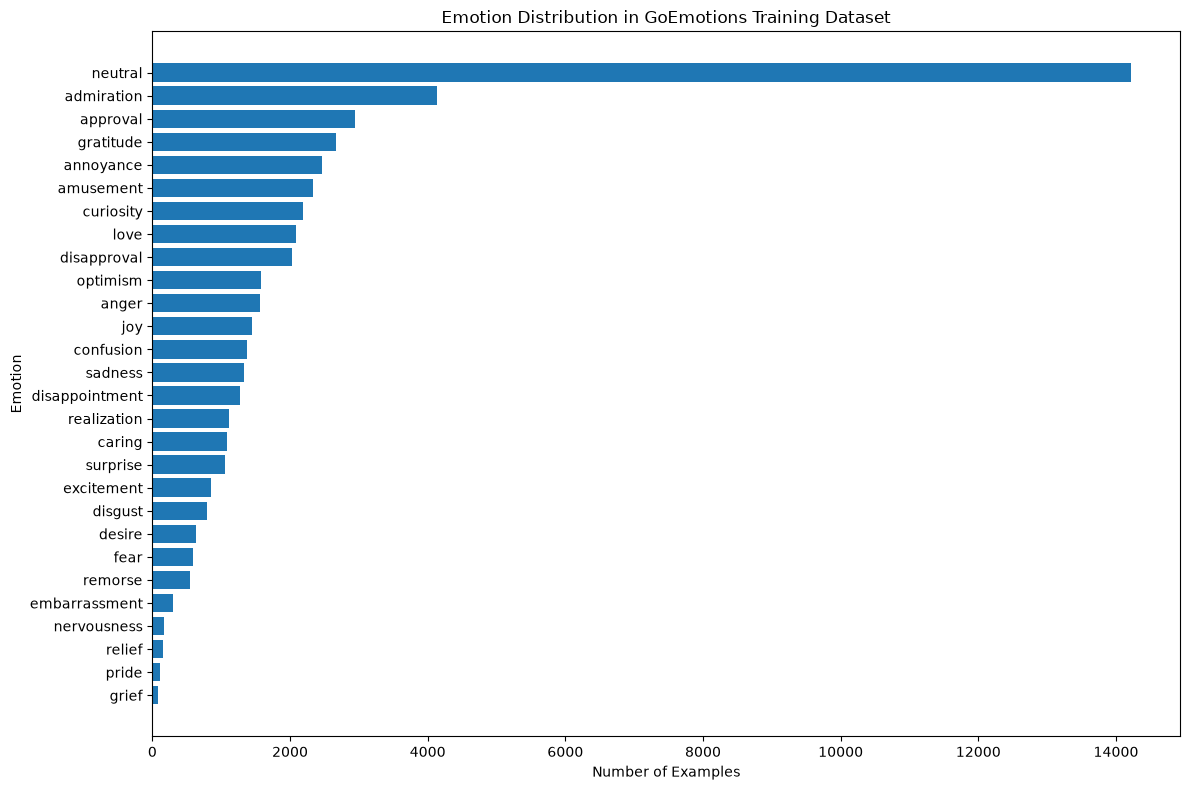

In [11]:
import matplotlib.pyplot as plt

# Sort emotions from most common to least common
sorted_emotions = sorted(
    emotion_distribution.items(),
    key=lambda x: x[1],
    reverse=True
)

emotions = [item[0] for item in sorted_emotions]
counts = [item[1] for item in sorted_emotions]

plt.figure(figsize=(12, 8))

plt.barh(emotions[::-1], counts[::-1])

plt.xlabel("Number of Examples")
plt.ylabel("Emotion")
plt.title("Emotion Distribution in GoEmotions Training Dataset")

plt.tight_layout()
plt.show()

In [12]:
for emotion, count in sorted_emotions:
    print(f"{emotion:15} {count}")

neutral         14219
admiration      4130
approval        2939
gratitude       2662
annoyance       2470
amusement       2328
curiosity       2191
love            2086
disapproval     2022
optimism        1581
anger           1567
joy             1452
confusion       1368
sadness         1326
disappointment  1269
realization     1110
caring          1087
surprise        1060
excitement      853
disgust         793
desire          641
fear            596
remorse         545
embarrassment   303
nervousness     164
relief          153
pride           111
grief           77


In [13]:
# Display examples for important emotions

important_emotions = [
    "nervousness",
    "fear",
    "sadness",
    "grief",
    "neutral"
]

for emotion in important_emotions:
    label_id = emotion_names.index(emotion)

    print("\n" + "=" * 60)
    print(f"EMOTION: {emotion.upper()}")
    print("=" * 60)

    count = 0

    for example in dataset["train"]:
        if label_id in example["labels"]:
            print("-", example["text"])
            count += 1

            if count == 5:
                break


EMOTION: NERVOUSNESS
- same but with panic at the disco
- Stuff like this makes me worry a little less about the future generations.
- also anxious that people will be angry or surprised or upset at me for me never telling people about this before
- Yeah, I do. I'm just pretty sure that that will fuck my heart eventually. But I'll worry about that later.
- This is pretty worrying and makes me wonder why she can’t. That’s not normal.

EMOTION: FEAR
- To make her feel threatened
- Your coaching is terrible.... be ready and see how [NAME] uses [NAME]
- He may have, I was more worried about the "running and shooting the AR one handed, off to the side".
-  I'm scared to even ask my mom ,I might get yelled at 😟
- Seeing that knife on this subreddit put the fear of [NAME] in me

EMOTION: SADNESS
- I miss them being alive
- Pretty sure I’ve seen this. He swings away with the harness he is wearing. Still looks painful but I think he lives
- sorry [NAME]! 😘😘😘
- my brain hurts...
- Go pursue tha

In [14]:
emotion_groups = {
    "anxiety_related": [
        "nervousness",
        "fear"
    ],

    "low_mood": [
        "sadness",
        "disappointment",
        "remorse"
    ],

    "grief_loss": [
        "grief"
    ],

    "anger_frustration": [
        "anger",
        "annoyance",
        "disapproval"
    ],

    "positive": [
        "joy",
        "amusement",
        "excitement",
        "gratitude",
        "love",
        "optimism",
        "relief",
        "admiration",
        "approval",
        "caring",
        "pride"
    ],

    "neutral_other": [
        "neutral",
        "curiosity",
        "confusion",
        "realization",
        "surprise",
        "desire",
        "disgust",
        "embarrassment"
    ]
}

print(emotion_groups)

{'anxiety_related': ['nervousness', 'fear'], 'low_mood': ['sadness', 'disappointment', 'remorse'], 'grief_loss': ['grief'], 'anger_frustration': ['anger', 'annoyance', 'disapproval'], 'positive': ['joy', 'amusement', 'excitement', 'gratitude', 'love', 'optimism', 'relief', 'admiration', 'approval', 'caring', 'pride'], 'neutral_other': ['neutral', 'curiosity', 'confusion', 'realization', 'surprise', 'desire', 'disgust', 'embarrassment']}


In [15]:
emotion_to_group = {}

for group, emotions in emotion_groups.items():
    for emotion in emotions:
        emotion_to_group[emotion] = group

print(emotion_to_group["nervousness"])
print(emotion_to_group["sadness"])
print(emotion_to_group["grief"])

anxiety_related
low_mood
grief_loss


In [16]:
emotion_to_group = {}

for group, emotions in emotion_groups.items():
    for emotion in emotions:
        emotion_to_group[emotion] = group

print(emotion_to_group["nervousness"])
print(emotion_to_group["sadness"])
print(emotion_to_group["grief"])

anxiety_related
low_mood
grief_loss


In [17]:
def get_mindmate_category(labels):
    """
    Convert the original GoEmotions labels
    into MindMate emotion categories.
    """

    original_emotions = [
        emotion_names[label]
        for label in labels
    ]

    categories = [
        emotion_to_group[emotion]
        for emotion in original_emotions
        if emotion in emotion_to_group
    ]

    # If an example has multiple emotions,
    # use the first mapped category for now.
    if categories:
        return categories[0]

    return "neutral_other"

In [18]:
example = dataset["train"][0]

print("Text:")
print(example["text"])

print("\nOriginal labels:")
print([
    emotion_names[label]
    for label in example["labels"]
])

print("\nMindMate category:")
print(get_mindmate_category(example["labels"]))

Text:
My favourite food is anything I didn't have to cook myself.

Original labels:
['neutral']

MindMate category:
neutral_other


In [19]:
train_texts = []
train_categories = []

for example in dataset["train"]:
    train_texts.append(example["text"])
    train_categories.append(
        get_mindmate_category(example["labels"])
    )

print("Total training examples:", len(train_texts))
print("Total categories:", len(train_categories))

Total training examples: 43410
Total categories: 43410


In [20]:
processed_train = pd.DataFrame({
    "text": train_texts,
    "emotion": train_categories
})

processed_train.head()


,text,emotion
0,My favourite food is anything I didn't have to...,neutral_other
1,"Now if he does off himself, everyone will thin...",neutral_other
2,WHY THE FUCK IS BAYLESS ISOING,anger_frustration
3,To make her feel threatened,anxiety_related
4,Dirty Southern Wankers,anger_frustration


In [21]:
category_counts = processed_train["emotion"].value_counts()

print(category_counts)

emotion
neutral_other        18683
positive             16405
anger_frustration     5336
low_mood              2306
anxiety_related        615
grief_loss              65
Name: count, dtype: int64


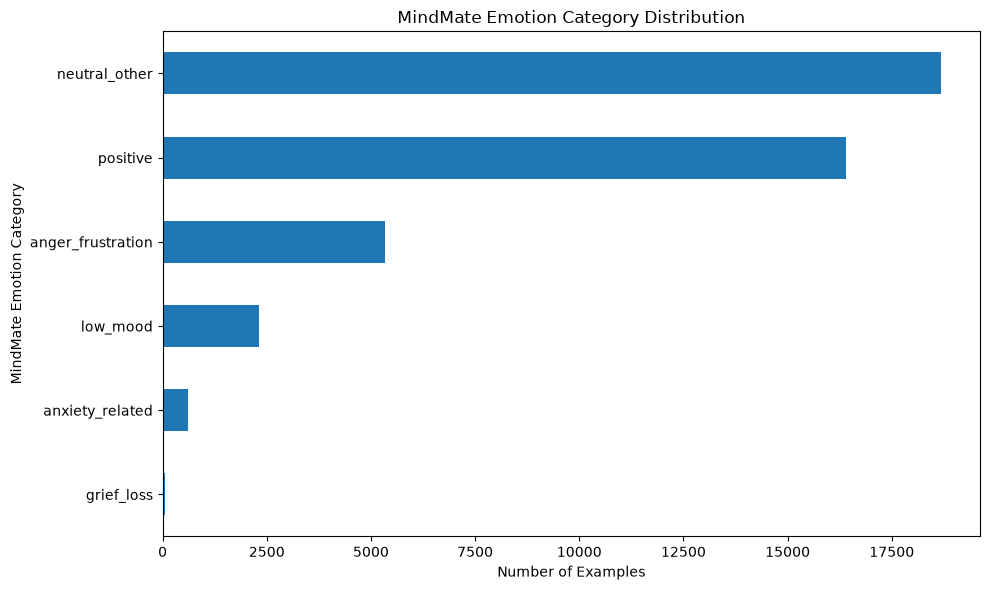

In [22]:
plt.figure(figsize=(10, 6))

category_counts.sort_values().plot(
    kind="barh"
)

plt.xlabel("Number of Examples")
plt.ylabel("MindMate Emotion Category")
plt.title("MindMate Emotion Category Distribution")

plt.tight_layout()
plt.show()

In [46]:
target_count = 2000

balanced_parts = []

for emotion, group in processed_train.groupby("emotion"):
    
    if emotion == "grief_loss":
        continue
    
    if len(group) >= target_count:
        sampled_group = group.sample(
            n=target_count,
            random_state=42
        )
    else:
        sampled_group = group.sample(
            n=target_count,
            replace=True,
            random_state=42
        )
    
    balanced_parts.append(sampled_group)

balanced_train = pd.concat(
    balanced_parts,
    ignore_index=True
)

print(balanced_train["emotion"].value_counts())

emotion
anger_frustration    2000
anxiety_related      2000
low_mood             2000
neutral_other        2000
positive             2000
Name: count, dtype: int64


In [47]:
balanced_train = balanced_train.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

balanced_train.head()

,text,emotion
0,that's me at the final stage.,neutral_other
1,Poor attempt for karma I think,low_mood
2,"[NAME], this isn't a guy who built the railro...",anger_frustration
3,Cali is getting rain this weekend so going to ...,low_mood
4,I am bored of [NAME]. Next celebrity chef!,low_mood


In [48]:
print(balanced_train["emotion"].value_counts())

emotion
neutral_other        2000
low_mood             2000
anger_frustration    2000
anxiety_related      2000
positive             2000
Name: count, dtype: int64


In [49]:
from sklearn.model_selection import train_test_split

# Check how many examples exist for each emotion
print("Emotion distribution:")
print(balanced_train["emotion"].value_counts())

# Separate text and emotion labels
X = balanced_train["text"]
y = balanced_train["emotion"]

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining examples:", len(X_train))
print("Validation examples:", len(X_val))

Emotion distribution:
emotion
neutral_other        2000
low_mood             2000
anger_frustration    2000
anxiety_related      2000
positive             2000
Name: count, dtype: int64

Training examples: 8000
Validation examples: 2000


In [50]:
print("Training distribution:")
print(y_train.value_counts())

print("\nValidation distribution:")
print(y_val.value_counts())

Training distribution:
emotion
anger_frustration    1600
neutral_other        1600
low_mood             1600
anxiety_related      1600
positive             1600
Name: count, dtype: int64

Validation distribution:
emotion
anger_frustration    400
anxiety_related      400
low_mood             400
positive             400
neutral_other        400
Name: count, dtype: int64


In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [52]:
model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 2),
            max_features=50000
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

In [53]:
print("Training MindMate emotion classifier...")

model.fit(X_train, y_train)

print("Training completed!")

Training MindMate emotion classifier...
Training completed!


In [54]:
print("Making predictions...")

y_pred = model.predict(X_val)

print("Predictions completed!")

Making predictions...
Predictions completed!


In [55]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_val, y_pred)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 63.95%


In [56]:
print(classification_report(y_val, y_pred))

                   precision    recall  f1-score   support

anger_frustration       0.52      0.52      0.52       400
  anxiety_related       0.90      0.93      0.92       400
         low_mood       0.67      0.61      0.64       400
    neutral_other       0.46      0.48      0.47       400
         positive       0.65      0.65      0.65       400

         accuracy                           0.64      2000
        macro avg       0.64      0.64      0.64      2000
     weighted avg       0.64      0.64      0.64      2000



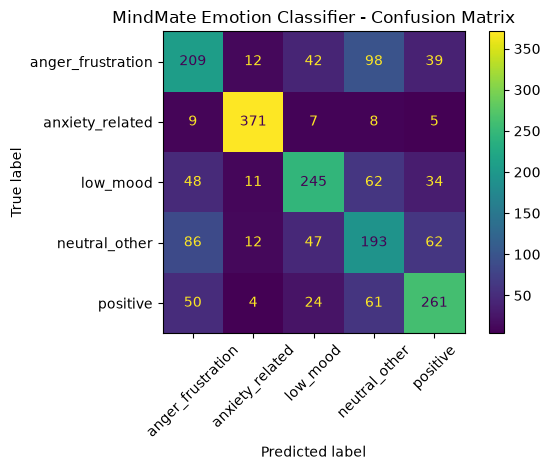

In [57]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_val,
    y_pred,
    labels=model.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(
    xticks_rotation=45
)

plt.title("MindMate Emotion Classifier - Confusion Matrix")
plt.tight_layout()
plt.show()

In [58]:
test_sentences = [
    "I feel really anxious about tomorrow.",
    "I am so happy that everything worked out!",
    "I am extremely angry about what happened.",
    "I have been feeling very low and sad lately.",
    "The meeting is scheduled for tomorrow."
]

predictions = model.predict(test_sentences)

for text, prediction in zip(test_sentences, predictions):
    print(f"Text: {text}")
    print(f"Predicted emotion: {prediction}")
    print("-" * 50)

Text: I feel really anxious about tomorrow.
Predicted emotion: anxiety_related
--------------------------------------------------
Text: I am so happy that everything worked out!
Predicted emotion: positive
--------------------------------------------------
Text: I am extremely angry about what happened.
Predicted emotion: anger_frustration
--------------------------------------------------
Text: I have been feeling very low and sad lately.
Predicted emotion: low_mood
--------------------------------------------------
Text: The meeting is scheduled for tomorrow.
Predicted emotion: anger_frustration
--------------------------------------------------


In [59]:
neutral_tests = [
    "The weather is sunny today.",
    "I live in Toronto.",
    "The meeting starts at 10 AM.",
    "I bought a new laptop yesterday.",
    "The package arrived this morning.",
    "She is studying computer science."
]

predictions = model.predict(neutral_tests)

for text, prediction in zip(neutral_tests, predictions):
    print(f"Text: {text}")
    print(f"Predicted emotion: {prediction}")
    print("-" * 50)

Text: The weather is sunny today.
Predicted emotion: low_mood
--------------------------------------------------
Text: I live in Toronto.
Predicted emotion: neutral_other
--------------------------------------------------
Text: The meeting starts at 10 AM.
Predicted emotion: anger_frustration
--------------------------------------------------
Text: I bought a new laptop yesterday.
Predicted emotion: low_mood
--------------------------------------------------
Text: The package arrived this morning.
Predicted emotion: neutral_other
--------------------------------------------------
Text: She is studying computer science.
Predicted emotion: anger_frustration
--------------------------------------------------


In [60]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

for emotion in processed_train["emotion"].unique():
    texts = processed_train[
        processed_train["emotion"] == emotion
    ]["text"]

    vectorizer = CountVectorizer(
        stop_words="english",
        max_features=15
    )

    vectorizer.fit(texts)

    print("\n" + "=" * 50)
    print(f"EMOTION: {emotion}")
    print("=" * 50)
    print(vectorizer.get_feature_names_out())


EMOTION: neutral_other
['did' 'didn' 'don' 'got' 'just' 'know' 'like' 'oh' 'people' 'really'
 'right' 'think' 'time' 've' 'want']

EMOTION: anger_frustration
['bad' 'doesn' 'don' 'fuck' 'fucking' 'hate' 'just' 'know' 'like' 'people'
 'really' 'shit' 'stupid' 'think' 'time']

EMOTION: anxiety_related
['afraid' 'anxiety' 'don' 'fear' 'horrible' 'just' 'like' 'makes' 'people'
 'really' 'scared' 'scary' 'terrible' 'terrifying' 'worried']

EMOTION: positive
['don' 'good' 'great' 'happy' 'hope' 'just' 'know' 'like' 'lol' 'love'
 'people' 'really' 'thank' 'thanks' 'think']

EMOTION: grief_loss
['away' 'better' 'condolences' 'dead' 'death' 'died' 'family' 'good'
 'hear' 'heart' 'loss' 'lost' 'rip' 'sorry' 'years']

EMOTION: low_mood
['bad' 'didn' 'don' 'feel' 'got' 'just' 'know' 'like' 'oh' 'people'
 'really' 'sad' 'sorry' 'time' 've']


In [61]:
print(model)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])


In [62]:
import os
import joblib

# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the trained pipeline
model_path = "../models/emotion_classifier.pkl"
joblib.dump(model, model_path)

print(f"Model saved successfully to: {model_path}")

Model saved successfully to: ../models/emotion_classifier.pkl


In [63]:
import joblib

loaded_model = joblib.load("../models/emotion_classifier.pkl")

print("Saved model loaded successfully!")

Saved model loaded successfully!


In [64]:
test_text = "I feel really worried about my future."

prediction = loaded_model.predict([test_text])[0]

print("Text:", test_text)
print("Predicted emotion:", prediction)

Text: I feel really worried about my future.
Predicted emotion: anxiety_related


In [65]:
anger_examples = balanced_train[
    balanced_train["emotion"] == "anger_frustration"
]

anger_examples[
    anger_examples["text"].str.contains(
        "furious|frustrated|frustration|enraged|rage",
        case=False,
        na=False
    )
][["text", "emotion"]].head(20)

,text,emotion
2134,People on the internet take shows too seriousl...,anger_frustration
2299,[NAME] voice actor by the end of the game was ...,anger_frustration
2374,"I mean I still attend regular school, this is ...",anger_frustration
2378,How dare you disparage a 3D printed JV riding ...,anger_frustration
2940,"Turn undead is once per short rest, you can’t ...",anger_frustration
3912,[NAME] just ripped his jersey. He’s frustrated...,anger_frustration
5159,Sexual frustration.,anger_frustration
6416,"They were not really messing around, just more...",anger_frustration
6545,Just another above average looking girl who wo...,anger_frustration
6998,i dont give a flaming fart about averages. mos...,anger_frustration


In [66]:
anger_examples = balanced_train[
    balanced_train["emotion"] == "anger_frustration"
]

words_to_check = [
    "furious",
    "frustrated",
    "frustration",
    "enraged",
    "rage",
    "angry"
]

for word in words_to_check:
    count = anger_examples["text"].str.contains(
        word,
        case=False,
        na=False
    ).sum()

    print(f"{word}: {count}")

furious: 1
frustrated: 4
frustration: 1
enraged: 0
rage: 10
angry: 23


In [67]:
extra_anger_examples = pd.DataFrame({
    "text": [
        "I am furious about what happened.",
        "I am absolutely furious right now.",
        "I feel furious and cannot believe this happened.",
        "I am extremely frustrated with this situation.",
        "I feel frustrated because nothing is working.",
        "This situation is making me really frustrated.",
        "I am enraged by what happened.",
        "I am so angry that I can barely think.",
        "I am furious and extremely angry.",
        "I feel completely frustrated and annoyed."
    ],
    "emotion": [
        "anger_frustration",
        "anger_frustration",
        "anger_frustration",
        "anger_frustration",
        "anger_frustration",
        "anger_frustration",
        "anger_frustration",
        "anger_frustration",
        "anger_frustration",
        "anger_frustration"
    ]
})

balanced_train = pd.concat(
    [balanced_train, extra_anger_examples],
    ignore_index=True
)

print("New dataset size:", len(balanced_train))

New dataset size: 10010


In [68]:
joblib.dump(
    model,
    "../models/emotion_classifier.pkl"
)

['../models/emotion_classifier.pkl']

In [69]:
import joblib

joblib.dump(
    model,
    "../models/emotion_classifier.pkl"
)

print("New model saved successfully!")

New model saved successfully!


In [70]:
import pandas as pd

extra_anger_examples = pd.DataFrame({
    "text": [
        "I am furious about what happened.",
        "I am absolutely furious right now.",
        "I feel furious and cannot believe this happened.",
        "I am extremely frustrated with this situation.",
        "I feel frustrated because nothing is working.",
        "This situation is making me really frustrated.",
        "I am enraged by what happened.",
        "I am so angry that I can barely think.",
        "I am furious and extremely angry.",
        "I feel completely frustrated and annoyed."
    ],
    "emotion": [
        "anger_frustration",
        "anger_frustration",
        "anger_frustration",
        "anger_frustration",
        "anger_frustration",
        "anger_frustration",
        "anger_frustration",
        "anger_frustration",
        "anger_frustration",
        "anger_frustration"
    ]
})

balanced_train = pd.concat(
    [balanced_train, extra_anger_examples],
    ignore_index=True
)

print("New dataset size:", len(balanced_train))

New dataset size: 10020


In [71]:
from sklearn.model_selection import train_test_split

X = balanced_train["text"]
y = balanced_train["emotion"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training examples:", len(X_train))
print("Validation examples:", len(X_val))

Training examples: 8016
Validation examples: 2004


In [72]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 2),
            max_features=50000
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

In [73]:
print("Training MindMate emotion classifier...")

model.fit(X_train, y_train)

print("Training completed!")

Training MindMate emotion classifier...
Training completed!


In [74]:
print(
    model.predict(
        ["I am furious about what happened."]
    )
)

print(
    model.predict_proba(
        ["I am furious about what happened."]
    )
)

['anger_frustration']
[[0.61173296 0.07030222 0.08786541 0.15820613 0.07189328]]


In [75]:
import joblib

joblib.dump(
    model,
    "../models/emotion_classifier.pkl"
)

print("New model saved successfully!")

New model saved successfully!
